In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import plotly.graph_objects as go
from scipy.ndimage import zoom
import cv2
from torchvision import transforms as T
import torchvision.transforms as T
import numpy as np
import os
import torch
from common import *
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import PIL
import PIL.Image
import cv2
from kemsekov_torch.positional_emb import PositionalEncodingPermute
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import affine_transform
import random
import skimage.measure
from scipy.ndimage import rotate
from scipy.spatial.transform import Rotation
from scipy.ndimage import gaussian_filter
from torch.cuda.amp import GradScaler, autocast



In [112]:

class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, info_dir, images_transform=None, projections_order=['a', 'b']):
        super().__init__()
        
        self.projections_order = projections_order
        
        # Считываем разметку
        labels = os.listdir(labels_dir)
        index_to_label = {i.split('.')[0]: os.path.join(labels_dir, i) for i in labels}
        
        # Считываем изображения
        images = os.listdir(images_dir)
        image_labels = [i.split("image")[1].split(".")[0] for i in images]
        
        data = {}
        for image, label in zip(images, image_labels):
            label_index = label[:-1]
            label_letter = label[-1]
            if label_index not in data:
                data[label_index] = {}
            data[label_index][label_letter] = os.path.join(images_dir, image)
        
        # Добавляем метки и проекции
        for i in index_to_label:
            row = data[i]
            row['label'] = index_to_label[i]
            projections = [row[p] for p in projections_order]
            row['projections'] = projections
        
        # Загружаем углы проекций из info файлов
        self.angles = {}
        info_files = os.listdir(info_dir)
        for info_file in info_files:
            if info_file.endswith(".info.0"):  # Фильтруем нужные файлы
                info_path = os.path.join(info_dir, info_file)
                with open(info_path, 'r') as f:
                    info_data = json.load(f)
                case_id = info_file.split('.')[0]  # ID кейса
                self.angles[case_id] = {
                    'theta': info_data.get("theta_array", []),
                    'phi': info_data.get("phi_array", [])
                }
        
        self.data = data
        self.keys = list(self.data.keys())
        self.images_transform = images_transform if images_transform else lambda x: T.ToTensor()(x)
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, index):
        key = self.keys[index]
        row = self.data[key]
        label = np.load(row['label'])
        images = [PIL.Image.open(v) for v in row['projections']]
        images = torch.concat([self.images_transform(i) for i in images])
        
        # Получаем углы для данного случая
        angles = self.angles.get(key, {'theta': [0] * len(self.projections_order), 'phi': [0] * len(self.projections_order)})
        theta = torch.tensor(angles['theta'], dtype=torch.float32)
        phi = torch.tensor(angles['phi'], dtype=torch.float32)
        
        return images, torch.tensor(label), theta, phi

In [113]:
# Пути к данным
images_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/images/test"
labels_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/labels/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0/content/vessel_tree_generator/data/test/info/"

# Трансформации для проекций
def mean_channel(x):
    return x.mean(axis=0)[None, :]

def distance_transform(image_mask):
    image_mask = np.asarray(image_mask)[0]
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask + distance[None, :])

images_transform = T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    T.Resize((128, 128)),
    T.Lambda(distance_transform),
])

# Загрузка данных
d2 = GeneratedDataset(images_dir, labels_dir, info_dir, images_transform=images_transform)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

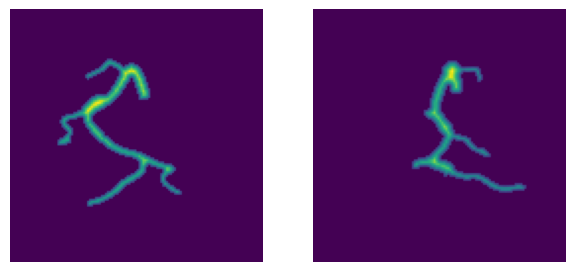

In [115]:
sample_index = 3 #random.randint(0,len(d)-1)
sample = d2[sample_index] #d2[1]
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(sample[0][0]) #d2[1][0][0]
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(sample[0][1])
plt.axis('off')

In [141]:
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy() #d2[1][0]
proj2 = images[1].cpu().numpy()
phi1, phi2 =phi[0].item(), phi[1].item()
theta1, theta2 = theta[0].item(), theta[1].item()
proj2.shape

(128, 128)

In [142]:
print(f'angle: theta1={theta1}, phi1={phi1},theta2={theta2}, phi2={phi2} ')

angle: theta1=-11.034991264343262, phi1=-102.16584014892578,theta2=-130.0, phi2=-102.03380584716797 


In [128]:
def normalize_tensor(sample):
    centerline_copy = sample*1.0
    slice = centerline_copy[..., :3]
    scale = float(slice.max() - slice.min())

    centerline_copy[..., :3] -= slice.min()
    centerline_copy[..., :3] /= scale if scale != 0.0 else 1.0
    centerline_copy[..., -1] /= scale if scale != 0.0 else 1.0
    return centerline_copy

# @torch.compile
# def create_shadow(projection, phi, theta, volume_shape=(128, 128, 128)):
#     D_x, D_y, D_z = volume_shape

#     projection = torch.tensor(projection, dtype=torch.float32)
#     h, w = projection.shape
#     vol = torch.zeros(volume_shape, dtype=torch.float32)
#     x0, y0 = (D_x - w) // 2, (D_y - h) // 2
#     vol[y0:y0+h, x0:x0+w, 0] = projection
#     y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
#     intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    
#     phi = torch.tensor(phi)
#     theta = torch.tensor(theta)
    
#     phi_rad, theta_rad = torch.tensor(torch.deg2rad(phi)), torch.tensor(torch.deg2rad(theta))
#     dx = torch.sin(theta_rad) * torch.cos(phi_rad)
#     dy = torch.sin(theta_rad) * torch.sin(phi_rad)
#     dz = -torch.cos(theta_rad)
#     norm = torch.sqrt(dx**2 + dy**2 + dz**2)
#     dx, dy, dz = dx / norm, dy / norm, dz / norm
#     z_indices = torch.arange(D_z, dtype=torch.long)
#     shadow_x = x_coords[:, None] + dx * z_indices[None, :]
#     shadow_y = y_coords[:, None] + dy * z_indices[None, :]
#     shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
#     shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
#     shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
#     shadow_z = shadow_z.clamp(0, D_z - 1)
#     for i in range(len(x_coords)):
#         for j in range(D_z):
#             if shadow_z[i, j] < D_z:
#                 vol[shadow_y[i, j], shadow_x[i, j], shadow_z[i, j]] = intensities[i]
#     return vol

@torch.compile
def create_shadow1(projection, phi, theta, volume_shape=(128, 128, 128)):
    D_x, D_y, D_z = volume_shape

    projection = torch.tensor(projection, dtype=torch.float32)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = projection
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    
    phi = torch.tensor(phi)
    theta = torch.tensor(theta)
    
    phi_rad, theta_rad = torch.tensor(torch.deg2rad(phi)), torch.tensor(torch.deg2rad(theta))
    # dx = torch.sin(theta_rad) * torch.cos(phi_rad)
    # dy = torch.sin(theta_rad) * torch.sin(phi_rad)
    # dz = -torch.cos(theta_rad)
    dx = torch.sin(phi_rad) * torch.cos(theta_rad)
    dy = torch.sin(phi_rad) * torch.sin(theta_rad)
    dz = -torch.cos(phi_rad)

    norm = torch.sqrt(dx**2 + dy**2 + dz**2)
    dx, dy, dz = dx / norm, dy / norm, dz / norm

    # Применяем coordSystemChanger
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32)
    direction = torch.tensor([dx, dy, dz], dtype=torch.float32)
    dx, dy, dz = torch.matmul(coordSystemChanger, direction).tolist()
    # Инвертируем направление для обратной проекции
    dx, dy, dz = -dx, -dy, -dz

    z_indices = torch.arange(D_z, dtype=torch.long)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for j in range(D_z):
        i_mask = shadow_z[:, j] < D_z
        vol[shadow_y[i_mask, j], shadow_x[i_mask, j], shadow_z[i_mask, j]] = intensities[i_mask]
    return vol

In [ ]:
from typing import List


# def create_output_model(output_3d_model : torch.Tensor, volume_shape : List[int]):
#     output_3d_model = normalize_tensor(output_3d_model)    
#     T = torch.zeros(volume_shape, dtype=torch.float32)

#     for group in range(output_3d_model.shape[0]):
#         x = (output_3d_model[group, :, 0] * 100 + 10).int().clip(0, 127)
#         y = (output_3d_model[group, :, 1] * 100 + 10).int().clip(0, 127)
#         z = (output_3d_model[group, :, 2] * 100 + 10).int().clip(0, 127)
#         R = torch.tensor(output_3d_model[group, :, 3], dtype=torch.float32) * 10
#         # print(f"Group {group} R min, max:", R.min().item(), R.max().item())
#         for i in range(len(x)):
#             radius = int((R[i] * 12).clamp(1, 10))
#             x_grid, y_grid, z_grid = torch.meshgrid(
#                 torch.arange(-radius, radius + 1),
#                 torch.arange(-radius, radius + 1),
#                 torch.arange(-radius, radius + 1)
#             )
#             mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
#             x_shifted = x[i] + x_grid[mask]
#             y_shifted = y[i] + y_grid[mask]
#             z_shifted = z[i] + z_grid[mask]
#             valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
#             x_valid, y_valid, z_valid = x_shifted[valid], y_shifted[valid], z_shifted[valid]


#             insertion_index =  T[x_valid, y_valid, z_valid] == 0
#             average_index    = T[x_valid, y_valid, z_valid] != 0

#             T[x_valid, y_valid, z_valid] += R[i]*insertion_index
            
#             avg = (R[i]+T[x_valid, y_valid, z_valid])/2
            
#             T[x_valid, y_valid, z_valid] +=  (avg-T[x_valid, y_valid, z_valid]) * average_index

#             # T[insertion_index]=R[i]
#             # T[average_index]=(T[average_index]+R[i])/2

#             # for x_v, y_v, z_v in zip(x_valid, y_valid, z_valid):
#             #     if T[x_v, y_v, z_v] == 0:
#             #         T[x_v, y_v, z_v] = R[i]
#             #     else:
#             #         T[x_v, y_v, z_v] = (T[x_v, y_v, z_v] + R[i]) / 2
#     return T



def create_output_model(output_3d_model: torch.Tensor, volume_shape: List[int]):
    output_3d_model = output_3d_model.clone()
    # Центрируем координаты, как в исходном коде
    mean_coords = output_3d_model[..., :3].mean(dim=(0, 1))
    output_3d_model[..., :3] -= mean_coords
    # Масштабируем для соответствия объёму
    scale = float(output_3d_model[..., :3].max() - output_3d_model[..., :3].min())
    output_3d_model[..., :3] /= scale if scale != 0.0 else 1.0
    output_3d_model[..., -1] /= scale if scale != 0.0 else 1.0
    # Отображаем на индексы объёма (0 до 127)
    output_3d_model[..., :3] = (output_3d_model[..., :3] * 100 + 64).int().clip(0, 127)  # Центр в 64

    T = torch.zeros(volume_shape, dtype=torch.float32)

    for group in range(output_3d_model.shape[0]):
        x = output_3d_model[group, :, 0].long()  # Преобразуем в long
        y = output_3d_model[group, :, 1].long()
        z = output_3d_model[group, :, 2].long()
        R = output_3d_model[group, :, 3] * 10
        for i in range(len(x)):
            radius = int((R[i] * 12).clamp(1, 10))
            x_grid, y_grid, z_grid = torch.meshgrid(
                torch.arange(-radius, radius + 1, dtype=torch.long),
                torch.arange(-radius, radius + 1, dtype=torch.long),
                torch.arange(-radius, radius + 1, dtype=torch.long)
            )
            mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
            # Гарантируем, что результат операций остаётся в типе long
            x_shifted = (x[i] + x_grid[mask]).long()
            y_shifted = (y[i] + y_grid[mask]).long()
            z_shifted = (z[i] + z_grid[mask]).long()
            
            # Проверяем, что координаты находятся в пределах объёма
            valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
            x_valid = x_shifted[valid]
            y_valid = y_shifted[valid]
            z_valid = z_shifted[valid]

            # Индексация тензора T
            insertion_index = T[x_valid, y_valid, z_valid] == 0
            average_index = T[x_valid, y_valid, z_valid] != 0

            T[x_valid, y_valid, z_valid] += R[i] * insertion_index
            avg = (R[i] + T[x_valid, y_valid, z_valid]) / 2
            T[x_valid, y_valid, z_valid] += (avg - T[x_valid, y_valid, z_valid]) * average_index

    return T

In [ ]:
def get_3d_tensors(projection1,projection2,correct_3d_geometry  ,tensor_output_shape=[128,128,128]):
    """
    Из двух двумерных проекций `projection1` (1,128,128), `projection2` (1,128,128) строит трехмерный тензор размером `tensor_output_shape` который содержит в себе тени от
    двумерных проекций.

    Из информации о ветках `correct_3d_geometry` (4,300,4) строит 3д тензор

    Возвращает два 3д тенозора размером `volume_shape`, первый из которых - тензор теней, второй - тензор с 3д геометрией
    """

    #phi1, phi2, theta1, theta2 = -40.0, 75.0, -10.0, -10.0 # какие здесь тетта и фи, вдоль каких осей ориентированы? 
    
    D_x, D_y, D_z = tensor_output_shape
    # Убедимся, что проекция — бинарная (0 или 1)
    #projection = (projection > 0).float()  # На случай, если остались небольшие значения
    # Масштабируем проекцию до размеров D_x, D_y

    projection1 = zoom(projection1.cpu(), (D_x / projection1.shape[0], D_y / projection1.shape[1]), order=1)
    projection2 = zoom(projection2.cpu(), (D_x / projection2.shape[0], D_y / projection2.shape[1]), order=1)

    projection1=torch.tensor(projection1).to(projection1.device)
    projection2=torch.tensor(projection2).to(projection2.device)

    shadow1 = create_shadow1(projection1, phi1, theta1, tensor_output_shape)
    shadow2 = create_shadow1(projection2, phi2, theta2, tensor_output_shape)
    backprojection = torch.stack([shadow1,shadow2])

    T = create_output_model(correct_3d_geometry.to(projection1.device), volume_shape = tensor_output_shape)
    return backprojection, T

backprojection, T = get_3d_tensors(sample[0][0].cuda(),sample[0][1].cuda(),sample[1].cuda())

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat2 in method wrapper_CUDA_bmm)

In [138]:
# Визуализация target_3d, shadow1 и shadow2
def visualize_3d_volume(volume, title="3D Reconstruction"):
    nonzero_indices = (volume > 0.01).nonzero(as_tuple=False)
    if len(nonzero_indices) > 0:
        if len(nonzero_indices) > 10000:
            indices = torch.randperm(len(nonzero_indices))[:10000]
            nonzero_indices = nonzero_indices[indices]
        values = volume[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]
        x_coords = nonzero_indices[:, 0].tolist()
        y_coords = nonzero_indices[:, 1].tolist()
        z_coords = nonzero_indices[:, 2].tolist()
        radii = values.tolist()
        fig = go.Figure(data=[go.Scatter3d(
            x=x_coords, y=y_coords, z=z_coords, mode='markers',
            marker=dict(size=3, color=radii, colorscale='Viridis', opacity=0.8, colorbar=dict(title="Value"))
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode='cube'),
            width=700, height=700,
            template="plotly_dark"
        )
        fig.show()
    else:
        print(f"No significant nonzero values (> 0.001) in {title} to visualize!")

# Визуализация
print("Visualizing target_3d...")
visualize_3d_volume(T.squeeze().squeeze(), title="Original 3D Target")
print("Visualizing shadow1...")
visualize_3d_volume(backprojection[1], title="Shadow 1")


Visualizing target_3d...


Visualizing shadow1...


In [139]:
import plotly.graph_objects as go
import torch
import numpy as np

def visualize_3d_volumes(shadow1, shadow2, T_trace, title="3D Shadows Reconstruction", sample_points=10000, threshold_factor=0.1):
    # Список для хранения данных трасс (traces)
    traces = []
    
    # Функция для извлечения координат из объёма с фильтрацией по интенсивности
    def get_volume_points(volume, color, name, threshold_factor=threshold_factor):
        # Адаптивный порог: берём threshold_factor * максимальное значение
        volume_max = volume.max()
        if volume_max > 0:
            threshold = threshold_factor * volume_max  # Порог, например, 10% от максимума
        else:
            threshold = 0.01  # Минимальный порог
        nonzero_indices = (volume > threshold).nonzero(as_tuple=False)
        
        if len(nonzero_indices) > 0:
            if len(nonzero_indices) > sample_points:
                indices = torch.randperm(len(nonzero_indices))[:sample_points]
                nonzero_indices = nonzero_indices[indices]
            x_coords = nonzero_indices[:, 0].tolist()
            y_coords = nonzero_indices[:, 1].tolist()
            z_coords = nonzero_indices[:, 2].tolist()
            return go.Scatter3d(
                x=x_coords, y=y_coords, z=z_coords, mode='markers',
                marker=dict(size=3, color=color, opacity=0.8),  # Фиксированный цвет
                name=name
            )
        return None
    
    # Добавляем shadow1 (красный цвет)
    shadow1_trace = get_volume_points(shadow1, 'blue', 'Shadow 1', threshold_factor)
    if shadow1_trace:
        traces.append(shadow1_trace)
    else:
        print("No significant nonzero values in shadow1 to visualize! Max value:", shadow1.max().item())
    
    # Добавляем shadow2 (синий цвет)
    shadow2_trace = get_volume_points(shadow2, 'green', 'Shadow 2', threshold_factor)
    if shadow2_trace:
        traces.append(shadow2_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", shadow2.max().item())
    T_trace = get_volume_points(T, 'red', 'T', threshold_factor)
    if T_trace:
        traces.append(T_trace)
    else:
        print("No significant nonzero values in shadow2 to visualize! Max value:", T_trace.max().item())
    # Если нет данных для отображения
    if not traces:
        print("No significant nonzero values (> threshold) to visualize!")
        return
    
    # Создаём график
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
            aspectmode='cube'
        ),
        width=800, height=800,
        template="plotly_dark",
        legend=dict(title="Objects")
    )
    fig.show()

# Пример использования
theta1, phi1 = sample[2][0].item(), sample[3][0].item()
theta2, phi2 = sample[2][1].item(), sample[3][1].item()
visualize_3d_volumes(backprojection[0], backprojection[1], T,  
                     title=f"Shadows (theta1={theta1:.1f}, phi1={phi1:.1f}, theta2={theta2:.1f}, phi2={phi2:.1f})")

In [140]:
print(f'angle: theta1={theta1}, phi1={phi1},theta2={theta2}, phi2={phi2} ')

angle: theta1=-11.034991264343262, phi1=-102.16584014892578,theta2=-130.0, phi2=-102.03380584716797 


In [172]:
def compute_direction(theta, phi, device='cuda:0'):
    # Преобразуем theta и phi в тензоры типа float32
    theta_rad = torch.deg2rad(torch.tensor(theta, dtype=torch.float32, device=device))
    phi_rad = torch.deg2rad(torch.tensor(phi, dtype=torch.float32, device=device))
    
    # Матрицы вращения в стандартной системе с типом float32
    R_theta = torch.tensor([
        [torch.cos(theta_rad), -torch.sin(theta_rad), 0],
        [torch.sin(theta_rad), torch.cos(theta_rad), 0],
        [0, 0, 1]
    ], dtype=torch.float32, device=device)
    
    R_phi = torch.tensor([
        [1, 0, 0],
        [0, torch.cos(phi_rad), torch.sin(phi_rad)],
        [0, -torch.sin(phi_rad), torch.cos(phi_rad)]
    ], dtype=torch.float32, device=device)
    
    # Матрица преобразования координат и её обратная с типом float32
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32, device=device)
    coordSystemChanger_inv = torch.inverse(coordSystemChanger.to(dtype=torch.float32)).to(device)
    
    # Применяем преобразование
    R_theta_transformed = torch.matmul(coordSystemChanger, torch.matmul(R_theta, coordSystemChanger_inv))
    R_phi_transformed = torch.matmul(coordSystemChanger, torch.matmul(R_phi, coordSystemChanger_inv))
    
    # Комбинированное вращение
    R = torch.matmul(R_theta_transformed, R_phi_transformed)
    
    # Начальный вектор [0, 0, 1] с типом float32
    vec = torch.tensor([0, 0, 1], dtype=torch.float32, device=device)
    
    # Вычисляем направление как тензор
    direction = torch.matmul(R, vec)
    
    # Для обратного проецирования инвертируем направление
    direction = -direction
    
    return direction  # Возвращаем тензор, а не список

def create_shadow1(projection, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape

    projection = torch.tensor(projection, dtype=torch.float32, device=device)
    h, w = projection.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32, device=device)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = projection
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    
    # Вычисляем направление
    dx, dy, dz = compute_direction(theta, phi, device=device)

    z_indices = torch.arange(D_z, dtype=torch.long, device=device)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for j in range(D_z):
        i_mask = shadow_z[:, j] < D_z
        vol[shadow_y[i_mask, j], shadow_x[i_mask, j], shadow_z[i_mask, j]] = intensities[i_mask]
    return vol

In [173]:
def create_output_model(output_3d_model: torch.Tensor, volume_shape: List[int], device='cuda:0'):
    output_3d_model = output_3d_model.clone().to(dtype=torch.float32, device=device)
    # Центрируем координаты
    mean_coords = output_3d_model[..., :3].mean(dim=(0, 1))
    output_3d_model[..., :3] -= mean_coords
    # Масштабируем для соответствия объёму
    scale = float(output_3d_model[..., :3].max() - output_3d_model[..., :3].min())
    output_3d_model[..., :3] /= scale if scale != 0.0 else 1.0
    output_3d_model[..., -1] /= scale if scale != 0.0 else 1.0

    # Применяем coordSystemChanger к координатам
    coordSystemChanger = torch.tensor([[0, -1, 0], [1, 0, 0], [0, 0, -1]], dtype=torch.float32, device=device)
    coords = output_3d_model[..., :3]  # [groups, points, 3]
    # Преобразуем координаты: [x, y, z] -> [-y, x, -z]
    coords_transformed = torch.einsum('ij,...j->...i', coordSystemChanger, coords)
    output_3d_model[..., :3] = coords_transformed

    # Отображаем на индексы объёма (0 до 127)
    output_3d_model[..., :3] = (output_3d_model[..., :3] * 100 + 64).int().clip(0, 127)

    T = torch.zeros(volume_shape, dtype=torch.float32, device=device)

    for group in range(output_3d_model.shape[0]):
        x = output_3d_model[group, :, 0].long()
        y = output_3d_model[group, :, 1].long()
        z = output_3d_model[group, :, 2].long()
        R = output_3d_model[group, :, 3] * 10
        for i in range(len(x)):
            radius = int((R[i] * 12).clamp(1, 10))
            x_grid, y_grid, z_grid = torch.meshgrid(
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device),
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device),
                torch.arange(-radius, radius + 1, dtype=torch.long, device=device)
            )
            mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
            x_shifted = (x[i] + x_grid[mask]).long()
            y_shifted = (y[i] + y_grid[mask]).long()
            z_shifted = (z[i] + z_grid[mask]).long()
            
            valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
            x_valid = x_shifted[valid]
            y_valid = y_shifted[valid]
            z_valid = z_shifted[valid]

            insertion_index = T[x_valid, y_valid, z_valid] == 0
            average_index = T[x_valid, y_valid, z_valid] != 0

            T[x_valid, y_valid, z_valid] += R[i] * insertion_index
            avg = (R[i] + T[x_valid, y_valid, z_valid]) / 2
            T[x_valid, y_valid, z_valid] += (avg - T[x_valid, y_valid, z_valid]) * average_index

    return T

/tmp/ipykernel_8546/3091735453.py:44: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



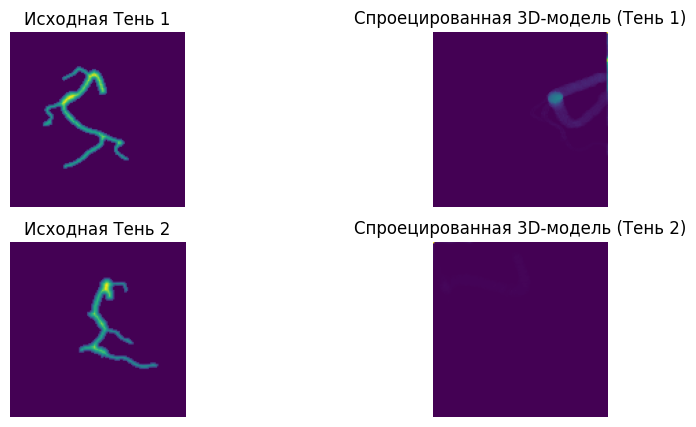

In [174]:
device = 'cuda:0'

# Преобразуем тензоры к float32 перед использованием
shadow1_input = sample[0][0].to(dtype=torch.float32, device=device)
shadow2_input = sample[0][1].to(dtype=torch.float32, device=device)
model_input = sample[1].to(dtype=torch.float32, device=device)

# Пересчитываем тени
shadow1 = create_shadow1(shadow1_input, phi1, theta1, device=device)
shadow2 = create_shadow1(shadow2_input, phi2, theta2, device=device)
backprojection = torch.stack([shadow1, shadow2])

# Пересчитываем T
T = create_output_model(model_input, volume_shape=[128, 128, 128], device=device)

# Визуализация
def project_3d_to_2d(volume, phi, theta, volume_shape=(128, 128, 128), device='cuda:0'):
    D_x, D_y, D_z = volume_shape
    projection = torch.zeros((D_x, D_y), dtype=torch.float32, device=device)
    
    dx, dy, dz = compute_direction(theta, phi, device=device)
    
    for z in range(D_z):
        for x in range(D_x):
            for y in range(D_y):
                if volume[y, x, z] > 0:
                    proj_x = (x + dx * z).round().clamp(0, D_x - 1).long()
                    proj_y = (y + dy * z).round().clamp(0, D_y - 1).long()
                    projection[proj_y, proj_x] += volume[y, x, z]
    
    return projection

proj1_3d = project_3d_to_2d(T, phi1, theta1, device=device)
proj2_3d = project_3d_to_2d(T, phi2, theta2, device=device)

# Преобразуем в CPU для визуализации
proj1_3d = proj1_3d.cpu()
proj2_3d = proj2_3d.cpu()

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(sample[0][0].cpu().numpy())
plt.title("Исходная Тень 1")
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(proj1_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 1)")
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(sample[0][1].cpu().numpy())
plt.title("Исходная Тень 2")
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(proj2_3d.numpy())
plt.title("Спроецированная 3D-модель (Тень 2)")
plt.axis('off')
plt.show()

In [108]:
backprojection, T_voxel, T_physical, shadow1_physical, shadow2_physical = get_3d_tensors(sample[0][0].cuda(), sample[0][1].cuda(), sample[1].cuda())
print("T_physical coords:", np.where(T_physical.cpu().numpy() > 0))
print("Shadow1_physical coords:", np.where(shadow1_physical.cpu().numpy() > 0))
print("Shadow2_physical coords:", np.where(shadow2_physical.cpu().numpy() > 0))

T_physical coords: (array([ 42,  42,  42, ..., 109, 109, 110]), array([ 65,  65,  65, ..., 100, 101, 100]), array([44, 45, 46, ..., 11, 10, 10]))
Shadow1_physical coords: (array([  0,   0,   0, ..., 127, 127, 127]), array([  0,   1,   1, ..., 125, 126, 127]), array([0, 0, 1, ..., 0, 0, 0]))
Shadow2_physical coords: (array([  0,   0,   0, ..., 127, 127, 127]), array([  0,   1,   2, ..., 127, 127, 127]), array([  0,   0,   0, ..., 125, 126, 127]))


/tmp/ipykernel_8546/1074398487.py:69: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



In [109]:
phi_rad, theta_rad = torch.deg2rad(phi1), torch.deg2rad(theta1)
dx = torch.sin(phi_rad) * torch.cos(theta_rad)
dy = torch.sin(phi_rad) * torch.sin(theta_rad)
dz = -torch.cos(phi_rad)
print(f"Projection 1 (dx, dy, dz): {dx.item()}, {dy.item()}, {dz.item()}")
phi_rad, theta_rad = torch.deg2rad(phi2), torch.deg2rad(theta2)
dx = torch.sin(phi_rad) * torch.cos(theta_rad)
dy = torch.sin(phi_rad) * torch.sin(theta_rad)
dz = -torch.cos(phi_rad)
print(f"Projection 2 (dx, dy, dz): {dx.item()}, {dy.item()}, {dz.item()}")

Projection 1 (dx, dy, dz): 0.6330222487449646, 0.7544065117835999, 0.1736481934785843
Projection 2 (dx, dy, dz): -0.949981153011322, 0.18789422512054443, 0.24946263432502747


In [ ]:
class BackprojectionDataset(torch.utils.data.Dataset):
    def __init__(self,two_proj_3d_dataset):
        super().__init__()
        self.two_proj_3d_dataset=two_proj_3d_dataset
    def __len__(self):
        return len(self.two_proj_3d_dataset)
    def __getitem__(self, index):
        
        sample = self.two_proj_3d_dataset[index]
        #sample[0] is two 2d projections
        #sample[1] is 3d

        # construct two 3d tensors
        # return
        return get_3d_tensors(...)
